# Recoupling shock — annual global means (Full-CPL, FC-FOSI-S1, FC-FOSI-S2)

Companion to `8_model_error_drift_analysis`, for the question **is there an initial shock when the FC-FOSI
spin-ups are recoupled to the fully coupled model?** FC-FOSI-S1/S2 run the FOSI phase for years 1–220 and are
fully coupled from year 221; Full-CPL is fully coupled throughout and is the "no recoupling" baseline over the
same model years.

**Data.** `post/time_series/atm/` monthly **area means** (Global, NH, SH) of the EAM variables, available for all
three runs (years 221–350; Full-CPL read from 201 for context) and for the piControl (years 1–500), which gives
the reference band. Gridded 10-yr climatologies (needed for e3sm_diags PCC/RMSE as in notebook 8) do not exist
for Full-CPL after year 250.

The figure shows annual global means; grey band = piControl mean ± 2σ of its annual means (experiments and piControl are not detrended).
Values outside the band right after year 221 that relax back are the recoupling shock.

Figures go to `FIG_DIR` (public_html), caches to `DATA_DIR` (`data/model_error_drift_10yr/`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from util.experiments import make_run_dict
from util.figures import publish
from util.area_mean_drift import DPM, load_or_read, plot_annual_timeseries

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/model_error_drift_10yr"
DATA_DIR     = f"{OUTPUT_ROOT}/data/model_error_drift_10yr" # cached/derived data (index: data/README.md)

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS          = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)
COLORS        = ["black", "#cc0000", "#377eb8"]    # one per experiment
YEARS         = (221, 350)      # model years analysed in every experiment
RECOUPLE_YEAR = 221             # first fully coupled year of the FC-FOSI runs
TS_YEARS      = {"Full-CPL": (201, 350)}   # longer read for the annual time series context (default YEARS)
REFERENCE     = ("Full-CPL", "piControl", (1, 500))   # fixed reference: experiment, segment, years

In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
out_dir  = DATA_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift_10yr
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift_10yr


## 1 Read monthly area means
`post/time_series/atm/{VAR}_YYYY01_YYYY12.nc` (5-yr files, `VAR(time, rgn)`) → one cached array
`(variable, year, month, region)` per run. Units are converted on read (precipitation and QFLX to mm/day,
pressures to hPa). The FC-FOSI files count time from `days since 0221-01-01`; the reader handles any reference date.

In [4]:
ts_sub    = "post/time_series/atm"
variables = ["FSNT", "FSNTOA", "FLUT", "FLNT",            # TOA radiation (+ derived RESTOM)
             "FSNS", "FLNS", "SHFLX", "QFLX",             # surface fluxes
             "PRECC", "PRECL", "PRECSC", "PRECSL",        # precipitation (+ derived PRECT)
             "CLDTOT", "CLDLOW", "CLDMED", "CLDHGH",      # clouds
             "TS", "TREFHT", "PS", "PSL", "ICEFRAC",      # state
             "TAUX", "TAUY"]                              # surface stress
# LANDFRAC (constant) and OCNFRAC (= 1 - LANDFRAC - ICEFRAC) are left out
derived   = ("PRECT", "RESTOM")
force_reprocess = False

monthly = {}
for e in EXPS:
    yrs  = TS_YEARS.get(e, YEARS)
    name = run_dict[e]["spin-up"]["name"]           # years 221-350 of the FC-FOSI runs live in the same case
    cache = os.path.join(out_dir, f"{e}_area_mean_monthly_{yrs[0]:04d}-{yrs[1]:04d}.nc")
    monthly[e] = load_or_read(cache, os.path.join(MODEL_ROOT, name, ts_sub), variables, yrs,
                              derived=derived, force=force_reprocess)

ref_exp, ref_seg, ref_years = REFERENCE
ref_name = run_dict[ref_exp][ref_seg]["name"]
reference = load_or_read(os.path.join(out_dir, f"piControl_area_mean_monthly_{ref_years[0]:04d}-{ref_years[1]:04d}.nc"),
                         os.path.join(MODEL_ROOT, ref_name, ts_sub), variables, ref_years,
                         derived=derived, force=force_reprocess)

for e, da in {**monthly, "piControl": reference}.items():
    sub = da.sel(year=slice(*YEARS)) if e != "piControl" else da
    print(f"{e:10s} years {int(da.year[0])}-{int(da.year[-1])}  missing months in analysis years: "
          f"{int(np.isnan(sub.isel(region=0)).sum())}")

Full-CPL   years 201-350  missing months in analysis years: 0
AltBG1     years 221-350  missing months in analysis years: 0
AltBG2     years 221-350  missing months in analysis years: 0
piControl  years 1-500  missing months in analysis years: 0


## 2 Annual global means around the recoupling
Annual global means; grey band = piControl mean ± 2σ of its annual means (nothing is detrended); dashed line = first coupled
year of the FC-FOSI runs. FC (Full-CPL) is shown from year 201 for context.

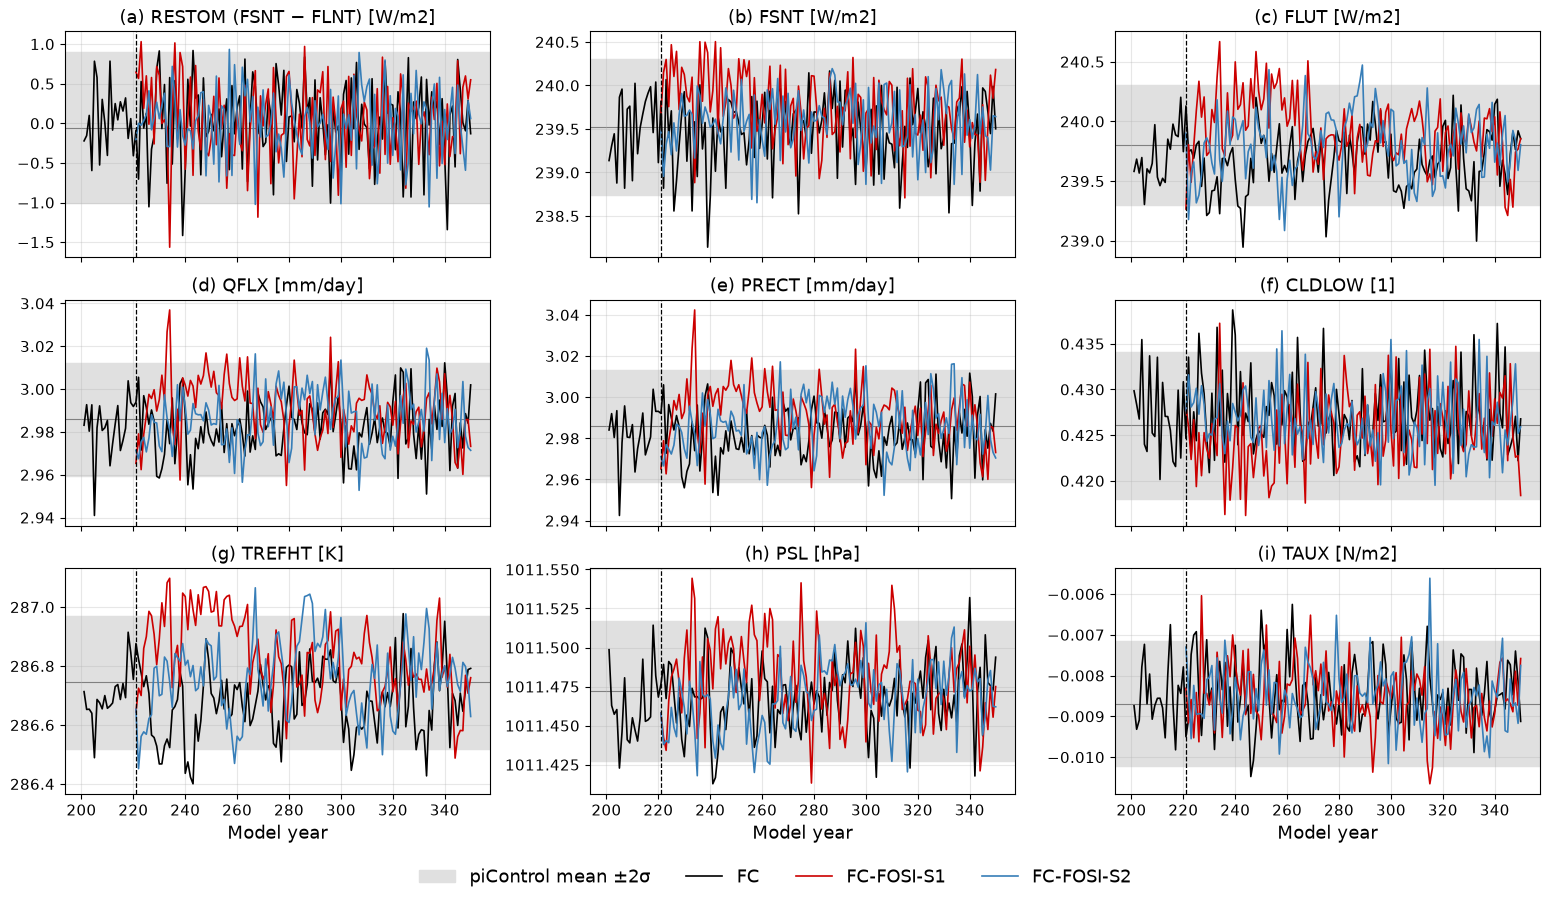

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_drift_10yr/ANN_timeseries_exp3_Global.pdf


In [5]:
ts_vars    = ["RESTOM", "FSNT", "FLUT", "QFLX", "PRECT", "CLDLOW", "TREFHT", "PSL", "TAUX"]
var_titles = {"RESTOM": "RESTOM (FSNT − FLNT)"}
region     = "Global"
sigma_band = 2.0

w = xr.DataArray(DPM, dims="month", coords={"month": np.arange(1, 13)})
annual     = {e: (monthly[e] * w).sum("month", skipna=False) / w.sum() for e in EXPS}
annual_ref = (reference * w).sum("month", skipna=False) / w.sum()

outfile = os.path.join(FIG_DIR, f"ANN_timeseries_exp3_{region}.pdf")
fig = plot_annual_timeseries(
    annual, exps=EXPS, explabels=[LABEL[e] for e in EXPS], colors=COLORS,
    variables=ts_vars, region=region, fig_path=outfile, reference=annual_ref,
    sigma_band=sigma_band, mark_year=RECOUPLE_YEAR, ncols=3, var_titles=var_titles,
    panel_labels=True,
)
plt.show()

publish(FIG_DIR, DATA_DIR)
print("web:", outfile.replace(OUTPUT_ROOT, OUTPUT_URL))